In [9]:
import pandas as pd
import numpy as np
import platform
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

def set_chinese_font():
    system = platform.system()
    if system == 'Windows':
        plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
    elif system == 'Darwin':  # macOS
        plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'Arial Unicode MS']
    else:  # Linux
        plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

set_chinese_font() 

In [2]:
# 2. 创建数据集
data = {
    '天气': ['晴天', '晴天', '阴天', '雨天', '雨天', '雨天', '阴天', '晴天', 
            '晴天', '雨天', '晴天', '阴天', '阴天', '雨天'],
    '温度': ['高', '高', '高', '适中', '冷', '冷', '冷', '适中', 
            '冷', '适中', '适中', '适中', '高', '适中'],
    '湿度': ['高', '高', '高', '高', '正常', '正常', '正常', '高', 
            '正常', '正常', '正常', '高', '正常', '高'],
    '刮风': [False, True, False, False, False, True, True, False, 
            False, False, True, True, False, True],
    '打球': ['否', '否', '是', '是', '是', '否', '是', '否', 
            '是', '是', '是', '是', '是', '否']
}

df = pd.DataFrame(data)
print("原始数据集：")
print(df)
print("\n数据集形状:", df.shape)

原始数据集：
    天气  温度  湿度     刮风 打球
0   晴天   高   高  False  否
1   晴天   高   高   True  否
2   阴天   高   高  False  是
3   雨天  适中   高  False  是
4   雨天   冷  正常  False  是
5   雨天   冷  正常   True  否
6   阴天   冷  正常   True  是
7   晴天  适中   高  False  否
8   晴天   冷  正常  False  是
9   雨天  适中  正常  False  是
10  晴天  适中  正常   True  是
11  阴天  适中   高   True  是
12  阴天   高  正常  False  是
13  雨天  适中   高   True  否

数据集形状: (14, 5)


In [3]:
# 3. 数据预处理（编码分类变量）
# 将文字特征转换为数值
le_weather = LabelEncoder()
le_temp = LabelEncoder()
le_humidity = LabelEncoder()
le_windy = LabelEncoder()
le_play = LabelEncoder()

# 对各列进行编码
df['天气编码'] = le_weather.fit_transform(df['天气'])
df['温度编码'] = le_temp.fit_transform(df['温度'])
df['湿度编码'] = le_humidity.fit_transform(df['湿度'])
df['刮风编码'] = le_windy.fit_transform(df['刮风'])
df['打球编码'] = le_play.fit_transform(df['打球'])

print("\n编码映射关系：")
print("天气:", dict(zip(le_weather.classes_, le_weather.transform(le_weather.classes_))))
print("温度:", dict(zip(le_temp.classes_, le_temp.transform(le_temp.classes_))))
print("湿度:", dict(zip(le_humidity.classes_, le_humidity.transform(le_humidity.classes_))))
print("刮风:", dict(zip(le_windy.classes_, le_windy.transform(le_windy.classes_))))
print("打球:", dict(zip(le_play.classes_, le_play.transform(le_play.classes_))))

print("\n编码后的数据集：")
print(df[['天气编码', '温度编码', '湿度编码', '刮风编码', '打球编码']])


编码映射关系：
天气: {'晴天': np.int64(0), '阴天': np.int64(1), '雨天': np.int64(2)}
温度: {'冷': np.int64(0), '适中': np.int64(1), '高': np.int64(2)}
湿度: {'正常': np.int64(0), '高': np.int64(1)}
刮风: {np.False_: np.int64(0), np.True_: np.int64(1)}
打球: {'否': np.int64(0), '是': np.int64(1)}

编码后的数据集：
    天气编码  温度编码  湿度编码  刮风编码  打球编码
0      0     2     1     0     0
1      0     2     1     1     0
2      1     2     1     0     1
3      2     1     1     0     1
4      2     0     0     0     1
5      2     0     0     1     0
6      1     0     0     1     1
7      0     1     1     0     0
8      0     0     0     0     1
9      2     1     0     0     1
10     0     1     0     1     1
11     1     1     1     1     1
12     1     2     0     0     1
13     2     1     1     1     0


In [4]:
# 4. 准备特征和标签

# 特征列（X）和目标列（y）
feature_cols = ['天气编码', '温度编码', '湿度编码', '刮风编码']
X = df[feature_cols]
y = df['打球编码']

print("\n特征矩阵：")
print(X.head())
print("\n目标向量：")
print(y.head())


特征矩阵：
   天气编码  温度编码  湿度编码  刮风编码
0     0     2     1     0
1     0     2     1     1
2     1     2     1     0
3     2     1     1     0
4     2     0     0     0

目标向量：
0    0
1    0
2    1
3    1
4    1
Name: 打球编码, dtype: int64


In [5]:
# 5. 划分数据集（80%训练，20%测试）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n训练集大小: {len(X_train)}")
print(f"测试集大小: {len(X_test)}")


训练集大小: 11
测试集大小: 3


In [6]:
# 6. 决策树模型

# 创建决策树分类器
# 参数说明：
# criterion='entropy'：使用信息增益（也可用'gini'基尼系数）
# max_depth=3：最大深度，防止过拟合
# random_state=42：固定随机种子，确保结果可重复
dt_classifier = DecisionTreeClassifier(
    criterion='entropy',  # 使用信息增益
    max_depth=3,
    random_state=42,
    min_samples_split=2  # 内部节点再划分所需最小样本数
)

# 训练模型
dt_classifier.fit(X_train, y_train)

print("决策树模型训练完成！")
print(f"决策树深度: {dt_classifier.get_depth()}")
print(f"叶子节点数: {dt_classifier.get_n_leaves()}")

决策树模型训练完成！
决策树深度: 3
叶子节点数: 6


In [7]:
# 7. 预测与评估
# 预测
y_pred_train = dt_classifier.predict(X_train)
y_pred_test = dt_classifier.predict(X_test)

# 计算准确率
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("\n模型性能评估：")
print(f"训练集准确率: {train_accuracy:.2f}")
print(f"测试集准确率: {test_accuracy:.2f}")

# 详细分类报告
print("\n测试集分类报告：")
print(classification_report(y_test, y_pred_test, 
      target_names=le_play.classes_))

# 混淆矩阵
print("混淆矩阵：")
cm = confusion_matrix(y_test, y_pred_test)
print(cm)


模型性能评估：
训练集准确率: 1.00
测试集准确率: 0.67

测试集分类报告：
              precision    recall  f1-score   support

           否       0.50      1.00      0.67         1
           是       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3

混淆矩阵：
[[1 0]
 [1 1]]


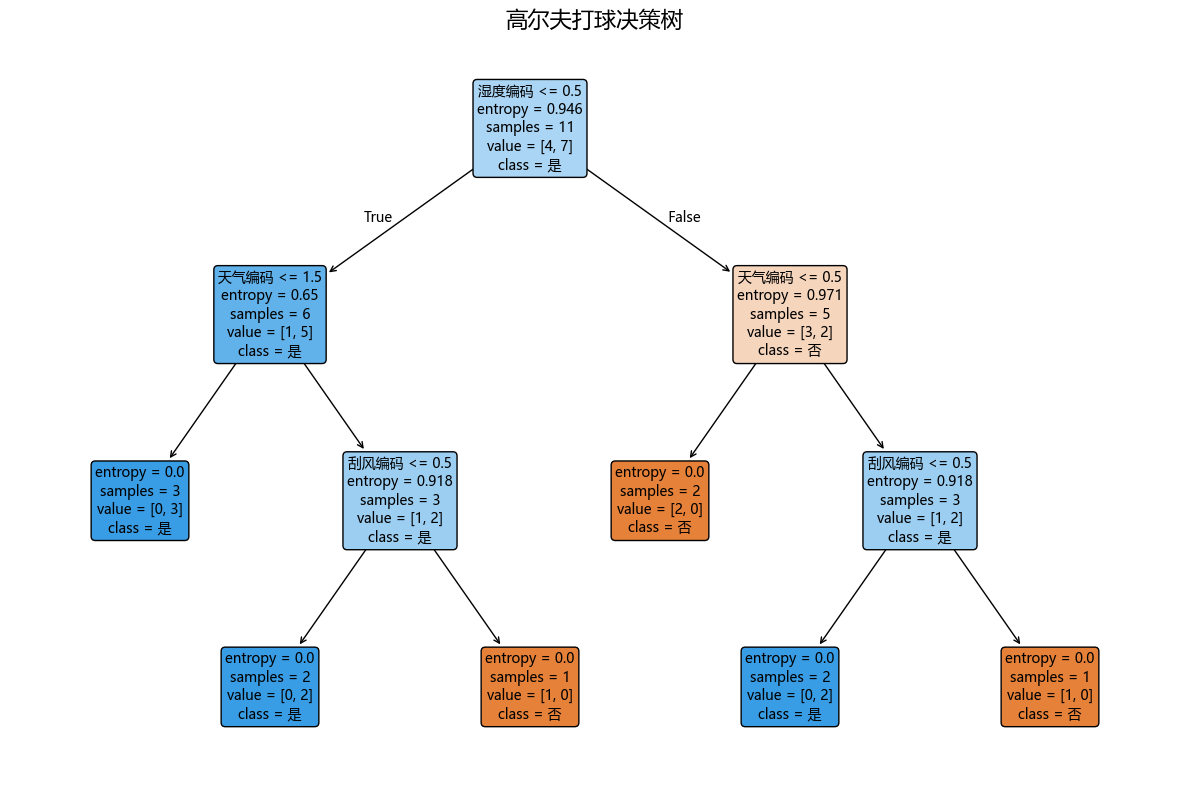


特征重要性：
     特征       重要性
3  刮风编码  0.529671
0  天气编码  0.311962
2  湿度编码  0.158367
1  温度编码  0.000000


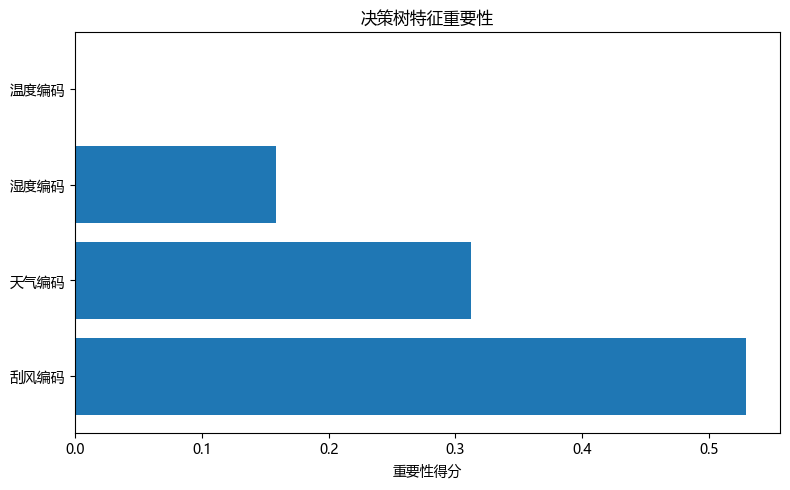

In [10]:
# 8. 可视化决策树

# 绘制决策树
plt.figure(figsize=(12, 8))
plot_tree(dt_classifier, 
          feature_names=feature_cols,
          class_names=le_play.classes_,
          filled=True,  # 填充颜色
          rounded=True,  # 圆角框
          fontsize=10)
plt.title("高尔夫打球决策树", fontsize=16)
plt.tight_layout()
plt.show()

# 特征重要性分析
feature_importance = pd.DataFrame({
    '特征': feature_cols,
    '重要性': dt_classifier.feature_importances_
}).sort_values('重要性', ascending=False)

print("\n特征重要性：")
print(feature_importance)

# 绘制特征重要性条形图
plt.figure(figsize=(8, 5))
plt.barh(feature_importance['特征'], feature_importance['重要性'])
plt.xlabel('重要性得分')
plt.title('决策树特征重要性')
plt.tight_layout()
plt.show()

In [11]:
# 9. 规则提取

# 提取决策规则
def extract_rules(tree, feature_names, class_names):
    """提取决策树规则"""
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != -2 else "undefined!"
        for i in tree_.feature
    ]
    
    rules = []
    def recurse(node, depth, rule):
        if tree_.feature[node] != -2:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            
            # 左子树规则
            left_rule = rule + [f"{name} <= {threshold:.2f}"]
            recurse(tree_.children_left[node], depth+1, left_rule)
            
            # 右子树规则
            right_rule = rule + [f"{name} > {threshold:.2f}"]
            recurse(tree_.children_right[node], depth+1, right_rule)
        else:
            # 叶子节点
            class_count = tree_.value[node][0]
            predicted_class = class_names[tree_.value[node].argmax()]
            rule_str = "IF " + " AND ".join(rule) + f" THEN {predicted_class}"
            rules.append((rule_str, class_count))
    
    recurse(0, 0, [])
    return rules

rules = extract_rules(dt_classifier, feature_cols, le_play.classes_)
print("\n决策规则：")
for rule, count in rules:
    print(f"{rule} (样本数: {count})")


决策规则：
IF 湿度编码 <= 0.50 AND 天气编码 <= 1.50 THEN 是 (样本数: [0. 1.])
IF 湿度编码 <= 0.50 AND 天气编码 > 1.50 AND 刮风编码 <= 0.50 THEN 是 (样本数: [0. 1.])
IF 湿度编码 <= 0.50 AND 天气编码 > 1.50 AND 刮风编码 > 0.50 THEN 否 (样本数: [1. 0.])
IF 湿度编码 > 0.50 AND 天气编码 <= 0.50 THEN 否 (样本数: [1. 0.])
IF 湿度编码 > 0.50 AND 天气编码 > 0.50 AND 刮风编码 <= 0.50 THEN 是 (样本数: [0. 1.])
IF 湿度编码 > 0.50 AND 天气编码 > 0.50 AND 刮风编码 > 0.50 THEN 否 (样本数: [1. 0.])


In [12]:
# 10. 新样本预测

# 创建新样本进行预测
def predict_play(weather, temp, humidity, windy):
    """预测是否打球"""
    # 编码输入
    weather_enc = le_weather.transform([weather])[0]
    temp_enc = le_temp.transform([temp])[0]
    humidity_enc = le_humidity.transform([humidity])[0]
    windy_enc = le_windy.transform([windy])[0]
    
    # 预测
    features = np.array([[weather_enc, temp_enc, humidity_enc, windy_enc]])
    prediction = dt_classifier.predict(features)[0]
    probability = dt_classifier.predict_proba(features)[0]
    
    result = le_play.inverse_transform([prediction])[0]
    
    print(f"\n预测结果：")
    print(f"天气: {weather}, 温度: {temp}, 湿度: {humidity}, 刮风: {windy}")
    print(f"预测: {result}")
    print(f"概率: 否={probability[0]:.2f}, 是={probability[1]:.2f}")
    return result

# 测试几个新样本
print("\n" + "="*50)
print("新样本预测示例：")
print("="*50)

predict_play('晴天', '高', '高', False)
predict_play('雨天', '适中', '正常', True)
predict_play('阴天', '冷', '正常', False)


新样本预测示例：

预测结果：
天气: 晴天, 温度: 高, 湿度: 高, 刮风: False
预测: 否
概率: 否=1.00, 是=0.00

预测结果：
天气: 雨天, 温度: 适中, 湿度: 正常, 刮风: True
预测: 否
概率: 否=1.00, 是=0.00

预测结果：
天气: 阴天, 温度: 冷, 湿度: 正常, 刮风: False
预测: 是
概率: 否=0.00, 是=1.00


i:\git\docs-public\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
i:\git\docs-public\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
i:\git\docs-public\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
i:\git\docs-public\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
i:\git\docs-public\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.w

'是'


最大深度 2:
  训练集准确率: 0.82
  测试集准确率: 0.33

最大深度 3:
  训练集准确率: 1.00
  测试集准确率: 0.67

最大深度 4:
  训练集准确率: 1.00
  测试集准确率: 0.67

最大深度 5:
  训练集准确率: 1.00
  测试集准确率: 0.67

最大深度 None:
  训练集准确率: 1.00
  测试集准确率: 0.67


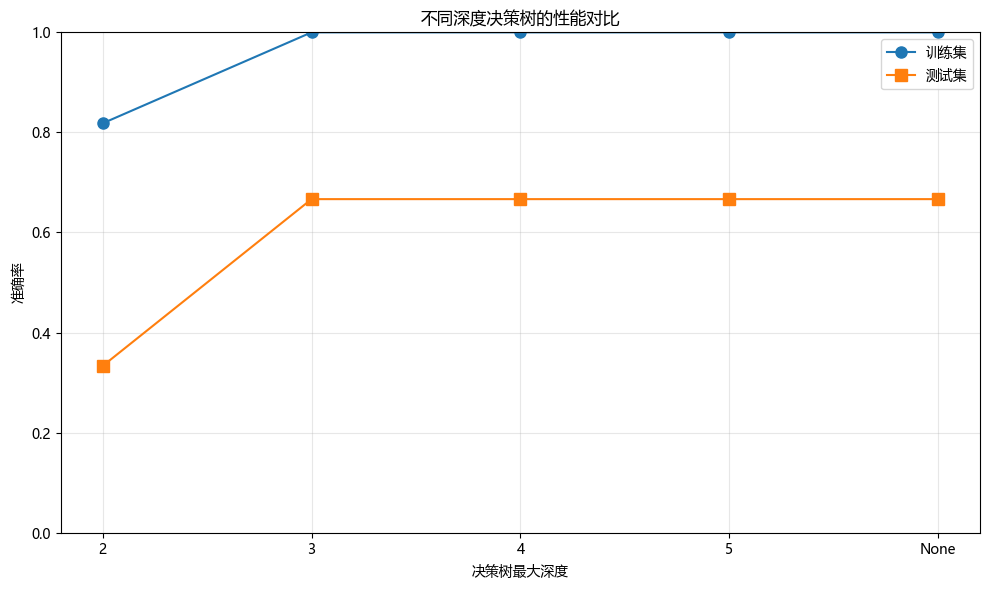

In [13]:
# 11. 不同参数对比

# 比较不同深度的决策树
depths = [2, 3, 4, 5, None]  # None表示不限制深度
train_scores = []
test_scores = []

for depth in depths:
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    
    depth_str = str(depth) if depth is not None else "None"
    print(f"\n最大深度 {depth_str}:")
    print(f"  训练集准确率: {train_acc:.2f}")
    print(f"  测试集准确率: {test_acc:.2f}")

# 绘制对比图
plt.figure(figsize=(10, 6))
depths_display = [str(d) if d is not None else 'None' for d in depths]
x_pos = range(len(depths_display))
plt.plot(x_pos, train_scores, 'o-', label='训练集', markersize=8)
plt.plot(x_pos, test_scores, 's-', label='测试集', markersize=8)
plt.xticks(x_pos, depths_display)
plt.xlabel('决策树最大深度')
plt.ylabel('准确率')
plt.title('不同深度决策树的性能对比')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

In [14]:
# overall

# 打印模型摘要
def model_summary():
    print("\n" + "="*60)
    print("决策树模型摘要")
    print("="*60)
    print(f"数据集大小: {len(df)} 条记录")
    print(f"特征数量: {len(feature_cols)}")
    print(f"类别: {list(le_play.classes_)}")
    print(f"决策树算法: ID3 (信息增益)")
    print(f"最大深度: {dt_classifier.get_depth()}")
    print(f"叶子节点数: {dt_classifier.get_n_leaves()}")
    print(f"训练集准确率: {train_accuracy:.2%}")
    print(f"测试集准确率: {test_accuracy:.2%}")
    print("\n最重要的特征:")
    print(feature_importance.to_string(index=False))

model_summary()


决策树模型摘要
数据集大小: 14 条记录
特征数量: 4
类别: ['否', '是']
决策树算法: ID3 (信息增益)
最大深度: 3
叶子节点数: 6
训练集准确率: 100.00%
测试集准确率: 66.67%

最重要的特征:
  特征      重要性
刮风编码 0.529671
天气编码 0.311962
湿度编码 0.158367
温度编码 0.000000
